## 1. Import Libraries

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

## 2. Download and Load MNIST Dataset

In [9]:
# Load the MNIST dataset directly from Keras
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


## 3. Preprocess Data: Reshape and Normalize Images

Images need to be reshaped to include a channel dimension (28x28x1 for grayscale) and normalized to a range between 0 and 1 for optimal model training.

In [10]:
# Reshape images to (height, width, channels) for CNN input
X_train_matrix = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test_matrix = X_test.reshape(-1, 28, 28, 1).astype('float32')

# Normalize pixel values to the range [0, 1]
X_train_matrix /= 255.0
X_test_matrix /= 255.0

print(f"Reshaped and normalized training data shape: {X_train_matrix.shape}")
print(f"Reshaped and normalized test data shape: {X_test_matrix.shape}")

Reshaped and normalized training data shape: (60000, 28, 28, 1)
Reshaped and normalized test data shape: (10000, 28, 28, 1)


## 4. Build the Convolutional Neural Network (CNN) Model

This CNN architecture consists of convolutional layers for feature extraction, max-pooling layers for downsampling, a flatten layer to convert the 2D feature maps into a 1D vector, and dense layers for classification.

In [11]:
model = Sequential([
    Input(shape=(28, 28, 1)),                  # Input layer, specifies image dimensions
    Conv2D(32, (3, 3), activation='relu'),     # First convolutional layer with 32 filters, 3x3 kernel
    MaxPooling2D((2, 2)),                      # Max-pooling layer to reduce spatial dimensions
    Conv2D(64, (3, 3), activation='relu'),     # Second convolutional layer with 64 filters
    MaxPooling2D((2, 2)),                      # Another max-pooling layer
    Flatten(),                                 # Flattens the 2D output to 1D for dense layers
    Dense(64, activation='relu'),              # Dense hidden layer with 64 units
    Dense(10, activation='softmax')            # Output layer with 10 units (for 10 digits), softmax for probabilities
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile the Model

Compiling the model involves specifying the optimizer, loss function, and metrics. For multi-class classification, `sparse_categorical_crossentropy` is suitable when labels are integers.

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 6. Train the Model

The model is trained using the training data (`X_train_matrix`, `y_train`). A portion of the training data is used for validation to monitor performance and prevent overfitting.

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9407 - loss: 0.1958 - val_accuracy: 0.9812 - val_loss: 0.0701
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.9822 - loss: 0.0586 - val_accuracy: 0.9888 - val_loss: 0.0474
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.9874 - loss: 0.0405 - val_accuracy: 0.9848 - val_loss: 0.0518
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.9902 - loss: 0.0305 - val_accuracy: 0.9855 - val_loss: 0.0496
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.9929 - loss: 0.0227 - val_accuracy: 0.9905 - val_loss: 0.0384


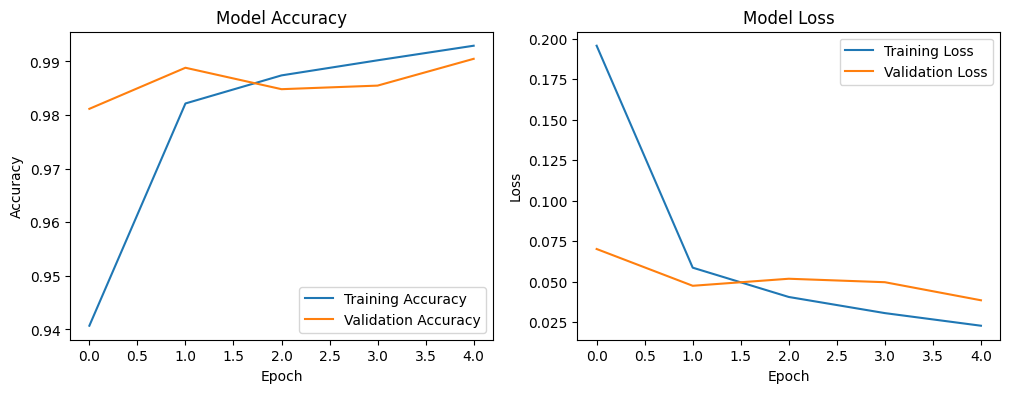

In [13]:
history = model.fit(
    X_train_matrix, y_train,
    epochs=5,                       # Number of times to iterate over the entire dataset
    batch_size=64,                  # Number of samples per gradient update
    validation_split=0.1,           # Use 10% of training data for validation
    verbose=1                       # Display progress bar during training
)

# Optional: Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 7. Evaluate the Model

After training, the model's performance is evaluated on the unseen test dataset to get an unbiased estimate of its generalization capability.

In [14]:
test_loss, test_acc = model.evaluate(X_test_matrix, y_test, verbose=0)
print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy : {test_acc * 100:.2f}%")


Final Test Loss: 0.0332
Final Test Accuracy : 98.91%


## 8. Predict and Plot Image Grid Results

To visually inspect the model's performance, we'll make predictions on a small subset of test images and display them alongside their true and predicted labels. Correct predictions will be highlighted in green, and incorrect ones in red.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


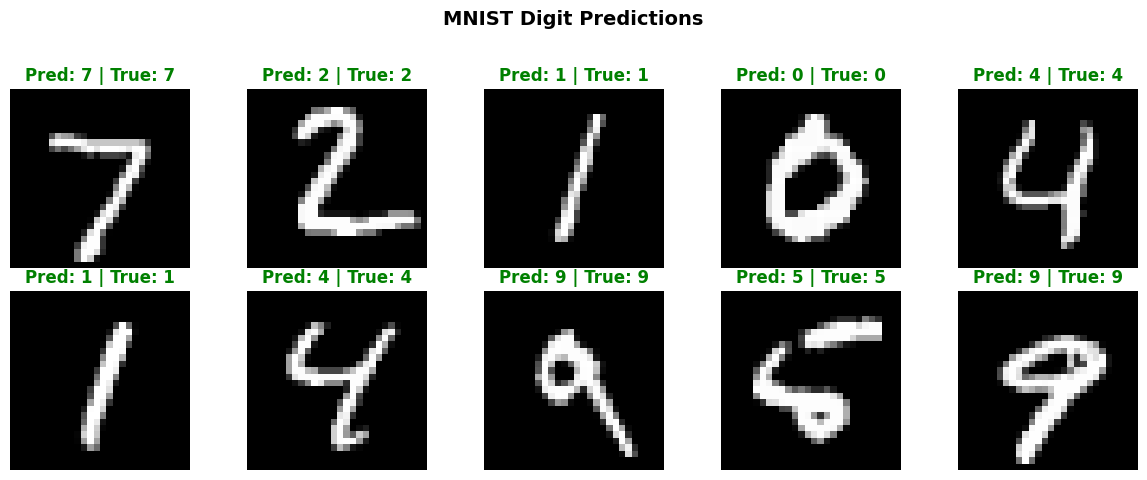

In [15]:
# Make predictions on the first 10 test images
predictions = model.predict(X_test_matrix[:10])

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i], cmap='gray') # Use original X_test for display
    pred_label = np.argmax(predictions[i]) # Get the predicted digit
    actual_label = y_test[i]            # Get the actual digit

    # Set title color based on prediction correctness
    color = 'green' if pred_label == actual_label else 'red'
    plt.title(f"Pred: {pred_label} | True: {actual_label}", color=color, fontweight='bold')
    plt.axis('off') # Hide axes

plt.suptitle("MNIST Digit Predictions", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()